<a href="https://colab.research.google.com/github/valentinacorreazta-pixel/Anal-tica-de-Negocios-/blob/main/clustering_k_Means_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Caso de Estudio
Una entidad fiannciera (FINTECH) quiere implementar un modelo de Clustering K-means de decisión para mejorar la preaprobación de créditos de consumo de sus solicitantes de este tipo de créditos. Para este proceso vamos a utlizar las variables:

Edad: indica el número de años que posee una perosna, o el tiempo que usted lleva en el sistema financiero.n
Ingresos: Engloba todos los ingresos que recibe una persona además si posee salario mensual (USD).
Egresos:
Monto: (EAD)

0. se procede con la carga de las librerias de trabajo

In [ ]:
from os import setns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # herramienta prara gráficas estadisticas
from sklearn.cluster import KMeans #herramienta de clustering

1. se cargan los datos de trabajo

<Axes: >

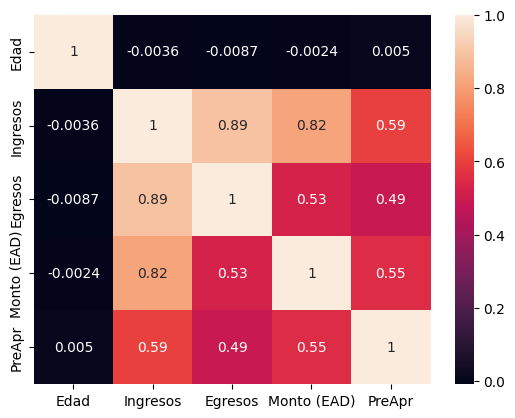

In [ ]:
nxl='/content/1. SolicitantesCrédito(USD) (2).xlsx'
XDB=pd.read_excel(nxl,sheet_name=1) #Base AAA
XD=XDB.iloc[:,[1,10,11,25]] # Datos de entrada
yd=XDB.iloc[:,32]

#Determinamos la correlación entre las variables
XDB2=XDB.iloc[:,[1,10,11,25,32]]
sns.heatmap(XDB2.corr(),annot=True)


buscar los valores mas altos que son los que tienen correlación mas alta (asi se ve cual tiene mayor influencia)

**Ánálisis de Resultados**

En el heatmap se puede observar que las variables que
tienen una mayor correlación entre ellas son las variables de ingresos y egresos con 89%. Esto indica que si una variable aumenta su alor, la otra tambien se incrementa (si gano mucho, gasto mucho).
Otra correlación de relevancia es la correlación entre ingresos y monto (0.82), personas con altos ingresos, piden montos mayores (bajos ingresos-montos menores). Se destaca que la variable que tiene una mayor correlación con la variable PreApro (salida) es la variable Ingreso (0,59).
De acuerdo con los segemtos o clusters arrojados por el modelo, podemos observar que el Cluster 1 y el Cluster 2 son los que poseen los ingresos más altos 1943 y 1378 respectivamente, clusters que igualmente son lo que tienen la menor cantidad de solicitantes de credito con 264 y 485. Se destaca el primer Cluster, el cual agrupa a las personas con menos ingresos (242), pero es el grupo que posee la mayor cantidad de solicitantes de credito (2127).

2. se procede con la implemetancion del modelo K-means




In [ ]:
np.random.seed(42) #son las semillas, el numero es el que permite generar las mismas semillas para todos (numeros aleatorios)
NC=5 #el 5, son los 5 segmentos de clientes (perfiles de clientes, 5 grupos de datos)
mkm=KMeans(n_clusters=NC,random_state=42)
mkm.fit(XD,yd) #El modelo busca la mejor relación entre la entrada y la salida

#obtenemos las caracteristicas de cada grupo
#Representa los perfiles de las perosnas mlm.cluster_ que encontró en el modelo
Tabla=pd.DataFrame(mkm.cluster_centers_,columns=XD.columns)
display(Tabla)

#Para saber los % de la posibilidad de que niegen o acepten el credito (de PreApro o PreNeg por segmento, sucursal, o perfil)
ydp=mkm.labels_ #esto me indica en que closter queda clasificado cada dato
NDc=np.bincount(ydp) #numero de datos por segmento
print("El número de datos por cluster es:", NDc)


,Edad,Ingresos,Egresos,Monto (EAD)
0,41.062353,242.798352,213.255141,175.381339
1,40.814394,1943.037897,2034.368232,1151.374380
2,40.842975,1378.277280,825.976626,1500.438821
3,40.995816,1173.957912,1239.367737,656.163350
4,41.129177,711.127537,601.939361,537.170724


El número de datos por cluster es: [2127  264  485  960 2006]


3. Porcentajes de PrAprobacióm


In [ ]:
XDB2['Cluster']=ydp #agregar columna adicional que se llama cluster
display(XDB2)

#DETRMINAR el numero de PreAprobados y PreNegados por Cluster
NApr=XDB2.groupby('Cluster').agg({"PreApr":lambda x: (x==1).sum()})
NPrn=XDB2.groupby('Cluster').agg({"PreApr":lambda x: (x==0).sum()})
df2=pd.DataFrame(np.column_stack((NApr,NPrn)),columns=['PreApr','PreNeg'])
#display(df2)

#para que la decisión sea en porcentaje
NApr2=NApr/(NApr+NPrn);NPrn2=NPrn/(NApr+NPrn)
df2=pd.DataFrame(np.column_stack((NApr2,NPrn2)),columns=['PreApr','PreNeg'])
display(df2)


/tmp/ipython-input-1146/3447369396.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XDB2['Cluster']=ydp #agregar columna adicional que se llama cluster


,Edad,Ingresos,Egresos,Monto (EAD),PreApr,Cluster
0,38,1356.14400,1685.622667,625.562230,1,3
1,51,286.01600,364.462000,140.031984,1,0
2,37,517.46325,629.208889,284.564492,0,4
3,29,473.27000,551.616889,309.647588,1,4
4,42,750.09175,806.715778,500.663578,1,4
...,...,...,...,...,...,...
5837,48,1207.84800,753.801111,748.041791,1,3
5838,31,1472.77200,953.812889,870.793819,1,3
5839,38,773.01975,672.910667,594.947894,1,4
5840,43,635.50175,780.691556,305.580539,1,4


,PreApr,PreNeg
0,0.137283,0.862717
1,0.962121,0.037879
2,0.973196,0.026804
3,0.772917,0.227083
4,0.559821,0.440179


Se puede obervar como el cluster 1 y 2, agrupan las probabilidades mas latas frnete a las preaprobación del créditos con un 96% y 97% de PreAprobación respectivamnete. Es importan†e mencionar que el cluster 0 tuvo lps menores porcentajes de PreAprobación, esto promovido por los menosres ingresos para las personas que hacen parte de este cluster.

4. Que pasa si aparece una nueva persona? edad:30, Ingresos:500, Egresos200, Monto:150

In [ ]:
import warnings
warnings.filterwarnings('ignore')# para que solo muestre lo que pido y no esos enlaces y demas
nueva_persona=np.array([30,500,200,150])
ydp=mkm.predict(nueva_persona.reshape(1,-1)) #reshape: quitarle la estructura
NCL=ydp[0] # esto indica el cluster al que pertenece una persona
print("La nueva persona pertenece al cluster:",ydp)
print("El porcentaje de preaprobación para la nueva persona es:",NApr2.iloc[NCL])
print("El porcentaje de prenegación para la nueva persona es:",NPrn2.iloc[NCL])

La nueva persona pertenece al cluster: [0]
El porcentaje de preaprobación para la nueva persona es: PreApr    0.137283
Name: 0, dtype: float64
El porcentaje de prenegación para la nueva persona es: PreApr    0.862717
Name: 0, dtype: float64




5.5. se procede con la gráfica de los clusters utilizando las variables Glucose y BMI


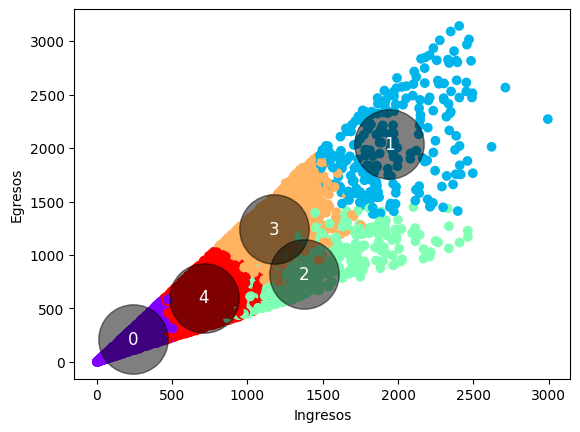

In [ ]:
centers=mkm.cluster_centers_ #centroides, Perfil o segmento
ing=np.array(XD.iloc[:,1]);egr=np.array(XD.iloc[:,2])

plt.figure()
plt.scatter(ing,egr,c=mkm.labels_,cmap='rainbow')# Use mkm.labels_ for all data points
plt.scatter(centers[:,1],centers[:,2],c='black',s=2500,alpha=0.5)
plt.xlabel("Ingresos")
plt.ylabel("Egresos")

#poner los numeros a los cluster correspondientes
for i, center in enumerate(centers):
  plt.text(center[1],center[2],str(i),color='white',fontsize=12,ha='center',va='center')
plt.show()


decir en que cluster quedo en cada uno, cluster uno tiene ingresos 1942, los egresos 2034. Los ingresos del cluster 0 son ..... lo ingresos del 3 son 1173 y los egresos son 1234...